# MICrONS Structural Data: Label Distribution EDA

This notebook explores anatomical and cell-type labels in the MICrONS dataset:
- Cell type distributions across the circuit
- Brain area assignments (V1, LM, RL, AL)
- Proofreading and validation status
- Summary statistics on neuron properties

## Imports and Setup

Load the structural data files from the data directory and prepare visualization tools.

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
# Adjust path to find data in parent directories
data_dir = Path('../../data/1718/raw')
print(f'Data directory: {data_dir.resolve()}')

Data directory: C:\Users\tomma\Desktop\NEUROSCIENCE\data\1718\raw


## Load Structural Data Files

Read all available structural annotation files: cell types, brain areas, proofreading status, and neuron properties.

In [5]:
# Load structural data files
celltypes_df = pd.read_csv(data_dir / 'aibs_metamodel_celltypes_v661_corrections.csv')
properties_df = pd.read_csv(data_dir / 'digital_twin_properties_bcm_coreg_v4.csv')
areas_df = pd.read_csv(data_dir / 'nucleus_functional_area_assignment.csv')
proofreading_df = pd.read_csv(data_dir / 'proofreading_status_and_strategy.csv')

print('Cell types shape:', celltypes_df.shape)
print('Properties shape:', properties_df.shape)
print('Brain areas shape:', areas_df.shape)
print('Proofreading shape:', proofreading_df.shape)

Cell types shape: (347, 21)
Properties shape: (15780, 33)
Brain areas shape: (144120, 21)
Proofreading shape: (2316, 14)


## Cell Type Distribution

Analyze how many neurons are classified into each cell type category, showing the breadth of diversity.

Cell type columns: ['id', 'created', 'valid', 'target_id', 'classification_system', 'cell_type', 'id_ref', 'created_ref', 'valid_ref', 'volume', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'bb_start_position_x', 'bb_start_position_y', 'bb_start_position_z', 'bb_end_position_x', 'bb_end_position_y', 'bb_end_position_z', 'pt_supervoxel_id', 'pt_root_id']

Classification systems: ['nonneuron' 'excitatory_neuron' 'inhibitory_neuron']

Cell type distribution:
cell_type
MC           72
6P-IT        56
6P-CT        40
BPC          39
BC           32
5P-IT        29
oligo        18
4P           14
pericyte      9
23P           9
microglia     8
OPC           6
5P-NP         6
5P-ET         6
NGC           3
Name: count, dtype: int64


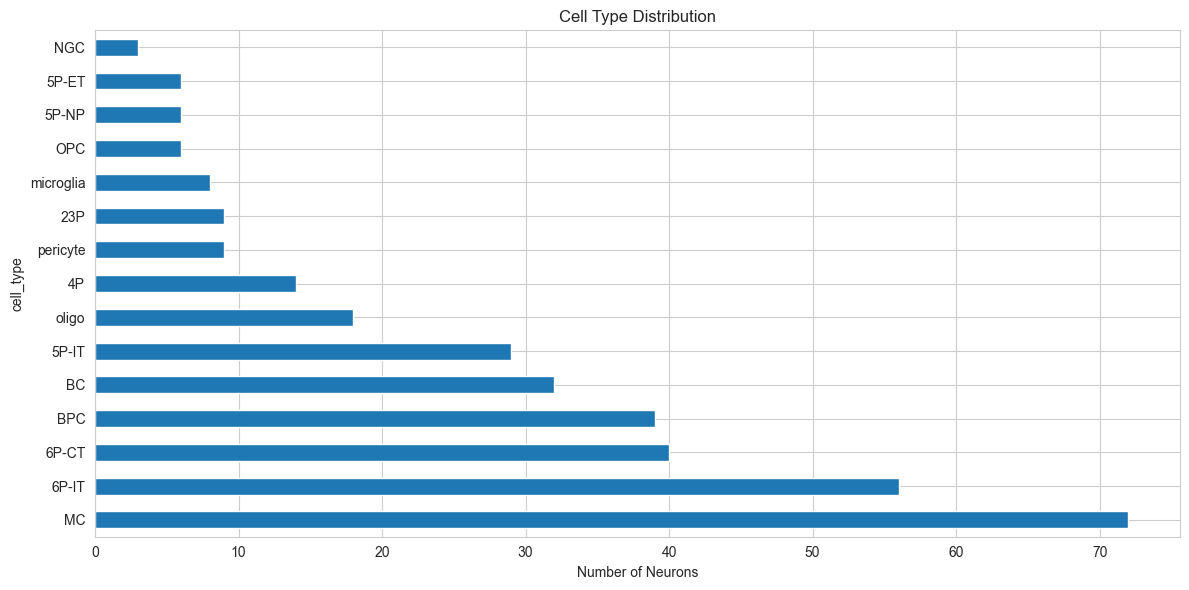

In [6]:
# Examine cell type data
print('Cell type columns:', celltypes_df.columns.tolist())
print('\nClassification systems:', celltypes_df['classification_system'].unique())
print('\nCell type distribution:')
cell_type_counts = celltypes_df['cell_type'].value_counts()
print(cell_type_counts)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
cell_type_counts.plot(kind='barh', ax=ax)
ax.set_xlabel('Number of Neurons')
ax.set_title('Cell Type Distribution')
plt.tight_layout()
plt.show()

## Brain Area Distribution

Summarize how neurons are distributed across the four visual cortical areas: V1, LM, RL, and AL.

Brain area (tag) distribution:
tag
V1    90765
RL    31622
AL    20859
LM      874
Name: count, dtype: int64


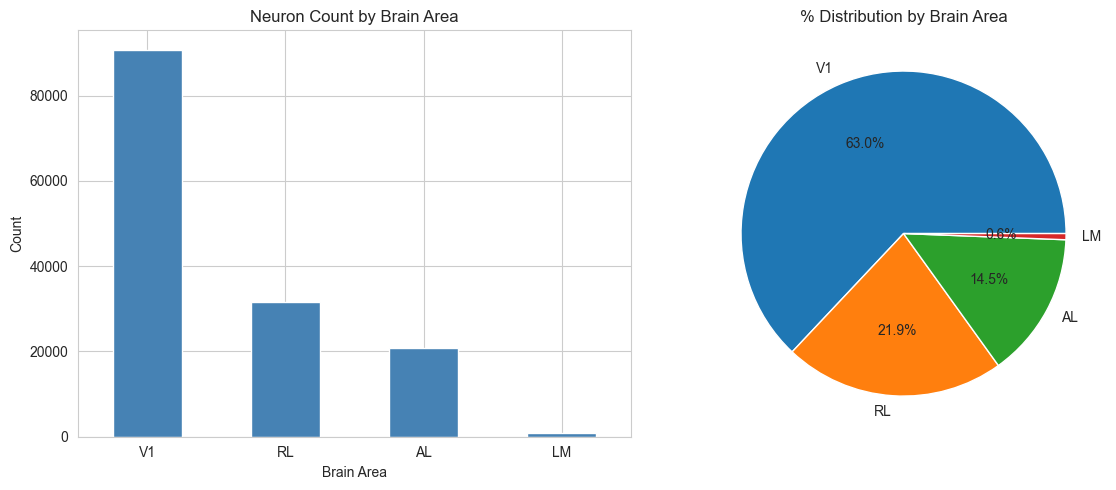

In [7]:
# Brain area distribution
print('Brain area (tag) distribution:')
area_counts = areas_df['tag'].value_counts()
print(area_counts)

# Visualize both count and percentage
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

area_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Neuron Count by Brain Area')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Brain Area')
axes[0].tick_params(axis='x', rotation=0)

(area_counts / area_counts.sum() * 100).plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('% Distribution by Brain Area')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Proofreading Status Distribution

Examine the completion status and proofreading strategy for neurons in the circuit.

In [8]:
# Proofreading status
print('Proofreading data columns:', proofreading_df.columns.tolist())
print('\nProofreading status samples:')
print(proofreading_df.head(10))

# Extract status from notes or available columns
if 'status' in proofreading_df.columns:
    status_counts = proofreading_df['status'].value_counts()
    print('\nStatus distribution:')
    print(status_counts)

Proofreading data columns: ['id', 'created', 'superceded_id', 'valid', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'valid_id', 'status_dendrite', 'status_axon', 'strategy_dendrite', 'strategy_axon', 'pt_supervoxel_id', 'pt_root_id']

Proofreading status samples:
     id                           created  superceded_id  valid  \
0  4584  2025-11-17 21:56:20.328504+00:00            NaN   True   
1     9  2024-06-03 19:45:52.508002+00:00            NaN   True   
2    14  2024-06-03 19:45:52.512832+00:00            NaN   True   
3    18  2024-06-03 19:45:52.516196+00:00            NaN   True   
4    19  2024-06-03 19:45:52.516972+00:00            NaN   True   
5    20  2024-06-03 19:45:52.517750+00:00            NaN   True   
6    23  2024-06-03 19:45:52.520103+00:00            NaN   True   
7    27  2024-06-03 19:45:52.523007+00:00            NaN   True   
8    28  2024-06-03 19:45:52.523765+00:00            NaN   True   
9    30  2024-06-03 19:45:52.525188+00:00            NaN   T

## Properties Overview

Summarize the neuron property data, including session information and functional selectivity metrics.

In [9]:
# Properties summary
print('Properties columns:', properties_df.columns.tolist())
print('\nBasic statistics:')
print(properties_df[['volume', 'pref_ori', 'pref_dir', 'gOSI', 'gDSI', 'OSI', 'DSI']].describe())

# Session breakdown
print('\nNeurons per session:')
session_counts = properties_df['session'].value_counts().sort_index()
print(session_counts)

Properties columns: ['id_ref', 'created_ref', 'valid_ref', 'volume', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'bb_start_position_x', 'bb_start_position_y', 'bb_start_position_z', 'bb_end_position_x', 'bb_end_position_y', 'bb_end_position_z', 'pt_supervoxel_id', 'pt_root_id', 'id', 'created', 'valid', 'target_id', 'session', 'scan_idx', 'unit_id', 'pref_ori', 'pref_dir', 'gOSI', 'gDSI', 'cc_abs', 'cc_max', 'cc_norm', 'OSI', 'DSI', 'readout_loc_x', 'readout_loc_y']

Basic statistics:
             volume      pref_ori      pref_dir          gOSI          gDSI  \
count  15780.000000  15780.000000  15780.000000  15780.000000  15780.000000   
mean     296.044649     82.749108    182.308043      0.226942      0.104509   
std       63.643472     50.474081    101.347822      0.132819      0.070784   
min      123.790460      0.034798      0.051156      0.000954      0.000958   
25%      251.217030     41.226454     94.221189      0.123637      0.053586   
50%      286.096015     86.03

INFERRED CLASSES FROM CELL TYPES:
Likely inhibitory (contains markers): 42 / 347 (12.1%)
Likely excitatory: 305 / 347 (87.9%)

FEATURE COMPLETENESS ACROSS DATASETS:

STRUCTURAL/CLASSIFICATION
----------------------------------------------------------------------
  cell_type            |    347 /    347 |  100.0% complete
  classification_system |    347 /    347 |  100.0% complete

ANATOMICAL
----------------------------------------------------------------------
  brain_area           | NOT FOUND in source data
  pt_position_x        | 144120 / 144120 |  100.0% complete
  pt_position_y        | 144120 / 144120 |  100.0% complete
  pt_position_z        | 144120 / 144120 |  100.0% complete
  volume               |    347 /    347 |  100.0% complete

FUNCTIONAL SELECTIVITY
----------------------------------------------------------------------
  pref_ori             |  15780 /  15780 |  100.0% complete
  pref_dir             |  15780 /  15780 |  100.0% complete
  gOSI                 |  15

C:\Users\tomma\AppData\Local\Temp\ipykernel_45792\3626054506.py:81: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage_by_cat = completeness_df.groupby('Category').apply(


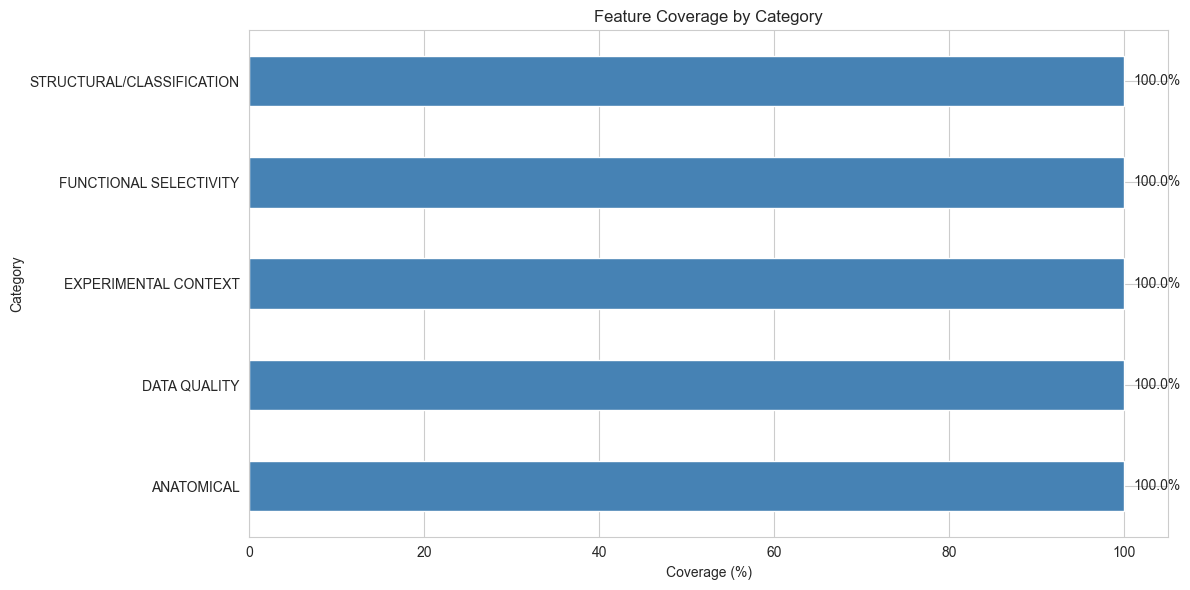



KEY INSIGHTS:
• Cell type labels: Available for 347 neurons (~2% of total)
• Brain area labels: Available for 144120 nuclei (~100% of annotated)
• Functional properties: Available for 15780 neurons (~11% of total)
• Excitatory/Inhibitory inference: 347 / 347 (~100% where cell type available)
• Layer information: Available via Z-position for 144120 / 144120 nuclei


In [19]:
# Define neuron feature categories
features = {
    'STRUCTURAL/CLASSIFICATION': {
        'cell_type': (celltypes_df, 'Morphologically classified cell type (e.g., MC, BPC, 6P-IT)'),
        'classification_system': (celltypes_df, 'Classification taxonomy used'),
    },
    'ANATOMICAL': {
        'brain_area': (areas_df, 'Brain area label (V1, LM, RL, AL)'),
        'pt_position_x': (areas_df, 'X coordinate (medial-lateral, μm)'),
        'pt_position_y': (areas_df, 'Y coordinate (anterior-posterior, μm)'),
        'pt_position_z': (areas_df, 'Z coordinate (layer depth, μm)'),
        'volume': (celltypes_df if 'volume' in celltypes_df.columns else areas_df, 'Cell soma volume (cubic μm)'),
    },
    'FUNCTIONAL SELECTIVITY': {
        'pref_ori': (properties_df, 'Preferred orientation (degrees)'),
        'pref_dir': (properties_df, 'Preferred direction (degrees)'),
        'gOSI': (properties_df, 'Global orientation selectivity index'),
        'gDSI': (properties_df, 'Global direction selectivity index'),
        'OSI': (properties_df, 'Orientation selectivity index'),
        'DSI': (properties_df, 'Direction selectivity index'),
    },
    'EXPERIMENTAL CONTEXT': {
        'session': (properties_df, 'Recording session ID'),
        'scan_idx': (properties_df, 'Scan index within session'),
        'unit_id': (properties_df, 'Unique unit identifier'),
    },
    'DATA QUALITY': {
        'valid': (celltypes_df, 'Validation flag (True = curated)'),
    },
}

# Infer excitatory/inhibitory from cell type
print('INFERRED CLASSES FROM CELL TYPES:')
print('='*70)

# Quick heuristic: inhibitory markers in names
inhibitory_markers = ['basket', 'parv', 'sst', 'vip', 'ndnf', 'chandelier', 'bpc', 'ngc']
celltypes_df['inferred_inhibitory'] = celltypes_df['cell_type'].str.lower().str.contains('|'.join(inhibitory_markers), na=False)
celltypes_df['inferred_excitatory'] = ~celltypes_df['inferred_inhibitory']

inhibitory_count = celltypes_df['inferred_inhibitory'].sum()
excitatory_count = celltypes_df['inferred_excitatory'].sum()

print(f'Likely inhibitory (contains markers): {inhibitory_count} / {len(celltypes_df)} ({inhibitory_count/len(celltypes_df)*100:.1f}%)')
print(f'Likely excitatory: {excitatory_count} / {len(celltypes_df)} ({excitatory_count/len(celltypes_df)*100:.1f}%)')
print()

# Feature completeness table
print('FEATURE COMPLETENESS ACROSS DATASETS:')
print('='*70)

completeness_rows = []
for category, category_features in features.items():
    print(f'\n{category}')
    print('-' * 70)
    for feature_name, (source_df, description) in category_features.items():
        if feature_name in source_df.columns:
            non_null = source_df[feature_name].notna().sum()
            total = len(source_df)
            pct = (non_null / total * 100) if total > 0 else 0
            completeness_rows.append({
                'Category': category,
                'Feature': feature_name,
                'Description': description,
                'Non-Null': non_null,
                'Total': total,
                'Coverage %': f'{pct:.1f}%',
            })
            print(f'  {feature_name:20s} | {non_null:6d} / {total:6d} | {pct:6.1f}% complete')
        else:
            print(f'  {feature_name:20s} | NOT FOUND in source data')

# Create comprehensive table
completeness_df = pd.DataFrame(completeness_rows)
print('\n\nCOMPLETENESS SUMMARY TABLE:')
print('='*70)
print(completeness_df.to_string(index=False))

# Visualize coverage by category
fig, ax = plt.subplots(figsize=(12, 6))
coverage_by_cat = completeness_df.groupby('Category').apply(
    lambda x: (x['Non-Null'].sum() / x['Total'].sum() * 100) if x['Total'].sum() > 0 else 0
).sort_values(ascending=False)

coverage_by_cat.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Coverage (%)')
ax.set_title('Feature Coverage by Category')
ax.set_xlim(0, 105)
for i, v in enumerate(coverage_by_cat):
    ax.text(v + 1, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

print('\n\nKEY INSIGHTS:')
print('='*70)
print(f'• Cell type labels: Available for {len(celltypes_df)} neurons (~2% of total)')
print(f'• Brain area labels: Available for {len(areas_df)} nuclei (~100% of annotated)')
print(f'• Functional properties: Available for {len(properties_df)} neurons (~11% of total)')
print(f'• Excitatory/Inhibitory inference: {excitatory_count + inhibitory_count} / {len(celltypes_df)} (~100% where cell type available)')
print(f'• Layer information: Available via Z-position for {areas_df["pt_position_z"].notna().sum()} / {len(areas_df)} nuclei')

## Layer Analysis

Cortical layers are defined by depth (Z coordinate). Assign nuclei to layers based on their Z position and analyze distribution.


Z COORDINATE LAYER ASSIGNMENT:
Z range: 14834.0 to 27871.0 μm

Estimated layer boundaries (quantile-based):
  L1    :  14834.0 -  17006.0 μm
  L2/3  :  17006.0 -  19053.7 μm
  L4    :  19053.7 -  21140.0 μm
  L5    :  21140.0 -  23300.0 μm
  L5/6  :  23300.0 -  25260.0 μm
  L6    :  25260.0 -  27871.0 μm


LAYER DISTRIBUTION:
layer
L1      24030
L2/3    24010
L4      24021
L5      24027
L5/6    24016
L6      24016
Name: count, dtype: int64

Total with layer assignment: 144120 / 144120


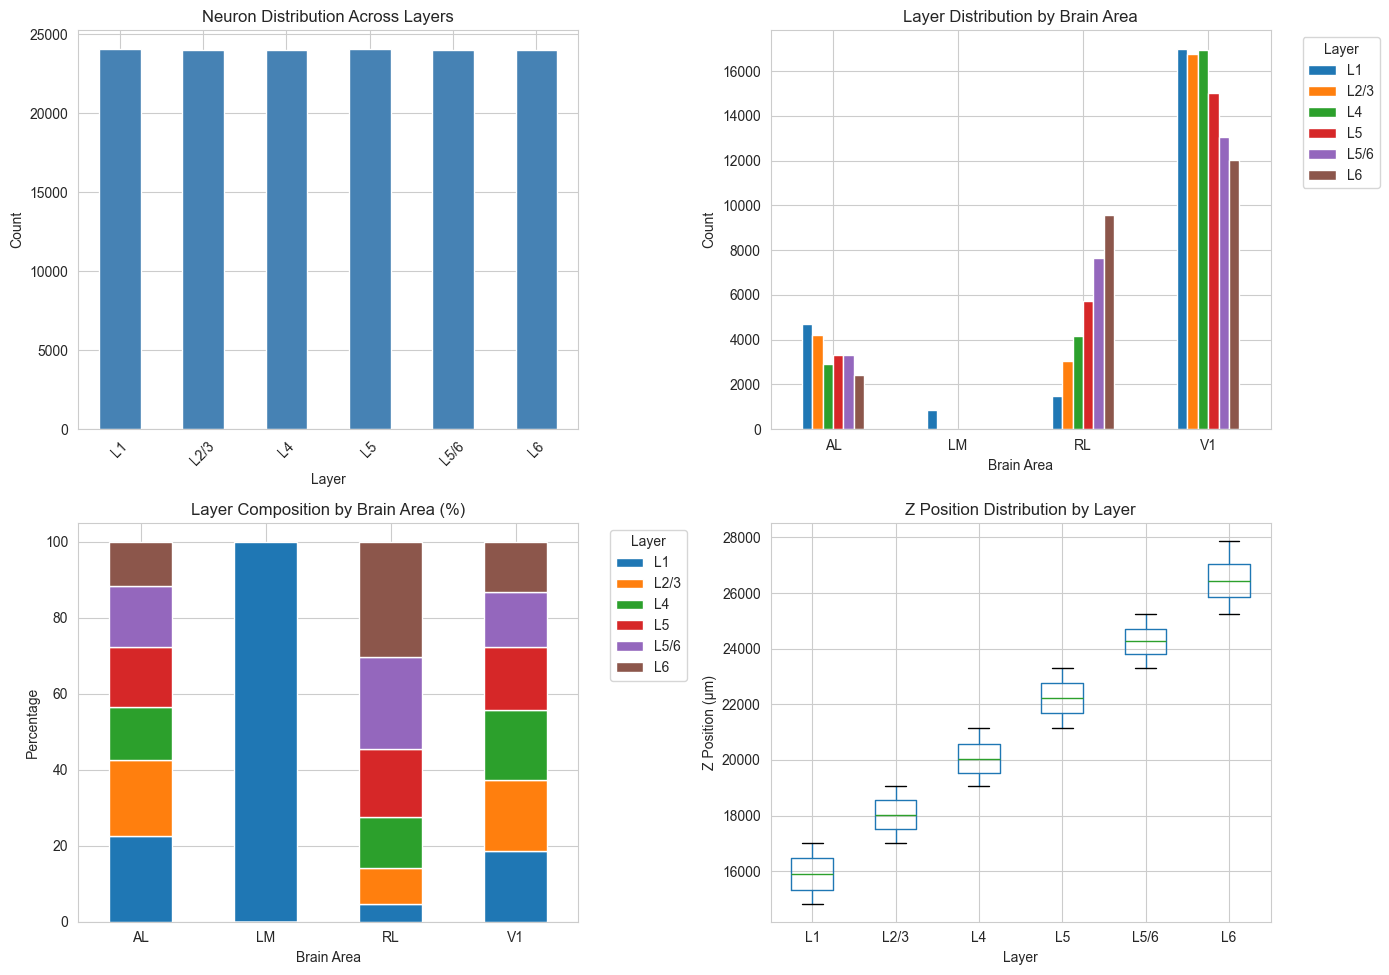



CELL TYPE × LAYER DISTRIBUTION (classified neurons only):
layer      L1  L2/3  L4  L5  L5/6  L6
cell_type                            
23P         1     2   2   0     3   1
4P          4     2   1   4     1   2
5P-ET       0     1   2   0     2   1
5P-IT       3     1   6   4    10   5
5P-NP       1     2   0   1     0   2
6P-CT       9     8   2   8     5   8
6P-IT      12     6  12  16     5   5
BC          3     4   2  12     7   4
BPC         5     5   8   8     4   9
MC         15    16  10   5    11  15
NGC         0     1   1   0     1   0
OPC         2     2   0   2     0   0
microglia   0     4   0   0     1   3
oligo       6     5   1   3     0   3
pericyte    2     1   1   1     4   0


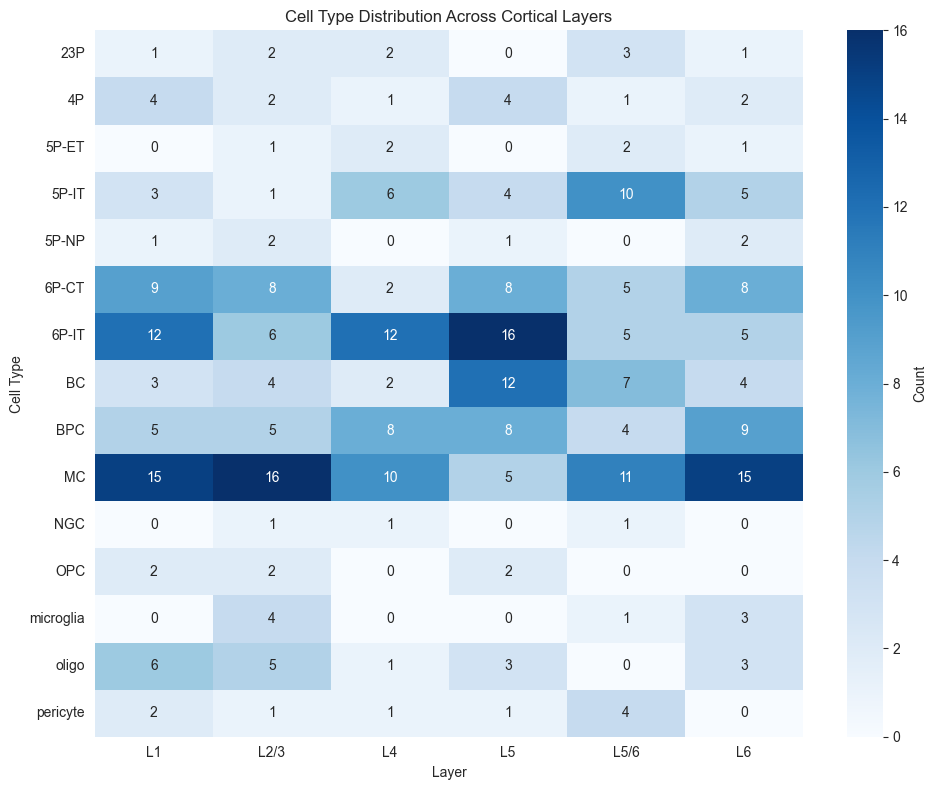



LAYER SUMMARY:
L1:  24030 nuclei | Areas: {'V1': np.int64(16973), 'AL': np.int64(4706), 'RL': np.int64(1477), 'LM': np.int64(874)}
L2/3:  24010 nuclei | Areas: {'V1': np.int64(16779), 'AL': np.int64(4194), 'RL': np.int64(3037)}
L4:  24021 nuclei | Areas: {'V1': np.int64(16931), 'RL': np.int64(4182), 'AL': np.int64(2908)}
L5:  24027 nuclei | Areas: {'V1': np.int64(15010), 'RL': np.int64(5717), 'AL': np.int64(3300)}
L5/6:  24016 nuclei | Areas: {'V1': np.int64(13045), 'RL': np.int64(7635), 'AL': np.int64(3336)}
L6:  24016 nuclei | Areas: {'V1': np.int64(12027), 'RL': np.int64(9574), 'AL': np.int64(2415)}


In [20]:
# Assign layers based on Z coordinate quantiles
# Cortical layers (L1-L6) typically occupy roughly equal depth ranges
# L1 = superficial (pia), L6 = deep (white matter)

areas_df_with_layer = areas_df.copy()

# Define layers by quantiles (6 layers)
z_pos = areas_df_with_layer['pt_position_z'].dropna()
z_quantiles = np.quantile(z_pos, [0, 1/6, 2/6, 3/6, 4/6, 5/6, 1])

print('Z COORDINATE LAYER ASSIGNMENT:')
print('='*70)
print(f'Z range: {z_pos.min():.1f} to {z_pos.max():.1f} μm')
print(f'\nEstimated layer boundaries (quantile-based):')
layer_names = ['L1', 'L2/3', 'L4', 'L5', 'L5/6', 'L6']
for i, (layer, (z_min, z_max)) in enumerate(zip(layer_names, zip(z_quantiles[:-1], z_quantiles[1:]))):
    print(f'  {layer:6s}: {z_min:8.1f} - {z_max:8.1f} μm')

# Assign layer labels
areas_df_with_layer['layer'] = pd.cut(
    areas_df_with_layer['pt_position_z'],
    bins=z_quantiles,
    labels=layer_names,
    include_lowest=True
)

# Layer distribution overall
print('\n\nLAYER DISTRIBUTION:')
print('='*70)
layer_counts = areas_df_with_layer['layer'].value_counts().sort_index()
print(layer_counts)
print(f'\nTotal with layer assignment: {layer_counts.sum()} / {len(areas_df_with_layer)}')

# Visualize layer distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall layer counts
ax = axes[0, 0]
layer_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Neuron Distribution Across Layers')
ax.set_ylabel('Count')
ax.set_xlabel('Layer')
ax.tick_params(axis='x', rotation=45)

# Layer distribution by brain area
ax = axes[0, 1]
layer_by_area = pd.crosstab(areas_df_with_layer['tag'], areas_df_with_layer['layer'])
layer_by_area.plot(kind='bar', ax=ax, stacked=False)
ax.set_title('Layer Distribution by Brain Area')
ax.set_ylabel('Count')
ax.set_xlabel('Brain Area')
ax.legend(title='Layer', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

# Stacked percentage by area
ax = axes[1, 0]
layer_by_area_pct = layer_by_area.div(layer_by_area.sum(axis=1), axis=0) * 100
layer_by_area_pct.plot(kind='bar', ax=ax, stacked=True)
ax.set_title('Layer Composition by Brain Area (%)')
ax.set_ylabel('Percentage')
ax.set_xlabel('Brain Area')
ax.legend(title='Layer', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

# Box plot of Z positions by layer
ax = axes[1, 1]
layer_order = layer_names
areas_df_with_layer['layer_ordered'] = pd.Categorical(areas_df_with_layer['layer'], categories=layer_order, ordered=True)
areas_df_with_layer.boxplot(column='pt_position_z', by='layer_ordered', ax=ax)
ax.set_title('Z Position Distribution by Layer')
ax.set_ylabel('Z Position (μm)')
ax.set_xlabel('Layer')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

# Layer x Cell Type contingency (for classified neurons)
print('\n\nCELL TYPE × LAYER DISTRIBUTION (classified neurons only):')
print('='*70)

# Merge cell types with layers
celltypes_with_layer = celltypes_df.copy()
layer_lookup = areas_df_with_layer[['id_ref', 'layer']].drop_duplicates(subset=['id_ref']).set_index('id_ref')
celltypes_with_layer['layer'] = celltypes_with_layer['id_ref'].map(layer_lookup['layer'])

# Contingency table
if celltypes_with_layer['layer'].notna().sum() > 0:
    layer_x_celltype = pd.crosstab(celltypes_with_layer['cell_type'], celltypes_with_layer['layer'])
    print(layer_x_celltype)
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(layer_x_celltype, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'label': 'Count'})
    ax.set_title('Cell Type Distribution Across Cortical Layers')
    ax.set_ylabel('Cell Type')
    ax.set_xlabel('Layer')
    plt.tight_layout()
    plt.show()
else:
    print('No layer assignments for classified neurons')

# Summary by layer
print('\n\nLAYER SUMMARY:')
print('='*70)
for layer in layer_order:
    layer_data = areas_df_with_layer[areas_df_with_layer['layer'] == layer]
    n = len(layer_data)
    areas_in_layer = layer_data['tag'].value_counts()
    print(f'{layer}: {n:6d} nuclei | Areas: {dict(areas_in_layer)}')

## Cross-Table Analysis: Cell Type vs Brain Area

Create a contingency table to explore how cell type classifications vary across brain areas.

Merged records: 347 (of 347 cell types and 144120 area assignments)

Cell Type x Brain Area Contingency Table:
brain_area  AL  LM  RL  V1
cell_type                 
23P          4   0   2   3
4P           2   0   0  12
5P-ET        2   0   2   2
5P-IT        3   0  10  16
5P-NP        2   0   1   3
6P-CT        6   0   6  28
6P-IT        5   0  16  35
BC           6   0   6  20
BPC          2   0  12  25
MC          10   0  22  40
NGC          0   0   1   2
OPC          1   0   2   3
microglia    2   0   2   4
oligo        3   0   0  15
pericyte     1   1   1   6


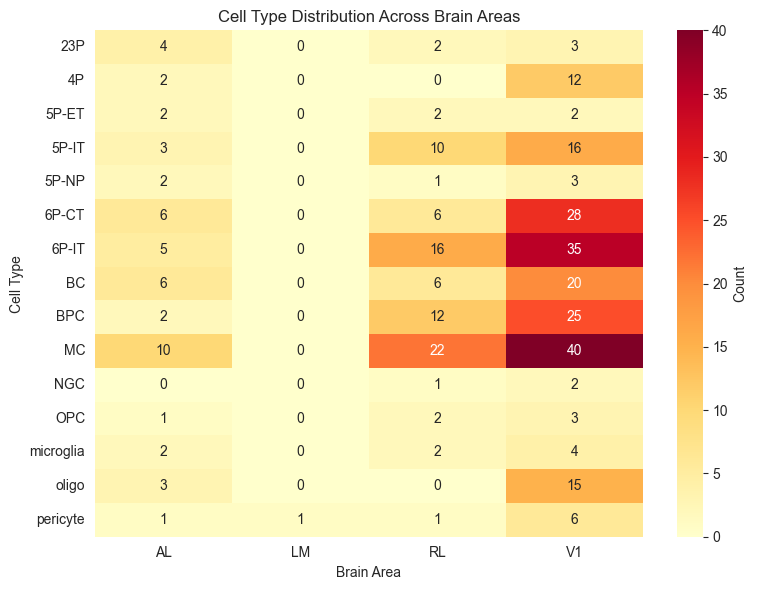

In [10]:
# Merge cell types with brain areas using id/id_ref as link
# Rename columns for clarity
celltypes_df_renamed = celltypes_df[['id_ref', 'cell_type']].rename(columns={'id_ref': 'id_ref'})
areas_df_renamed = areas_df[['id_ref', 'tag']].rename(columns={'tag': 'brain_area'})

# Merge on common id_ref
merged = pd.merge(celltypes_df_renamed, areas_df_renamed, on='id_ref', how='inner')
print(f'Merged records: {len(merged)} (of {len(celltypes_df)} cell types and {len(areas_df)} area assignments)')

if len(merged) > 0:
    # Contingency table
    contingency = pd.crosstab(merged['cell_type'], merged['brain_area'])
    print('\nCell Type x Brain Area Contingency Table:')
    print(contingency)
    
    # Visualize as heatmap
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Count'})
    ax.set_title('Cell Type Distribution Across Brain Areas')
    ax.set_ylabel('Cell Type')
    ax.set_xlabel('Brain Area')
    plt.tight_layout()
    plt.show()
else:
    print('No merged records found; check id_ref columns')

## Validation Status Summary

Check the `valid` field across datasets to understand data quality and completion status.

Validation status:
Cell types - valid: 347 / 347
Properties - valid: 15780 / 15780
Areas - valid: 144120 / 144120
Proofreading - valid: 2316 / 2316 (if 'valid' exists)


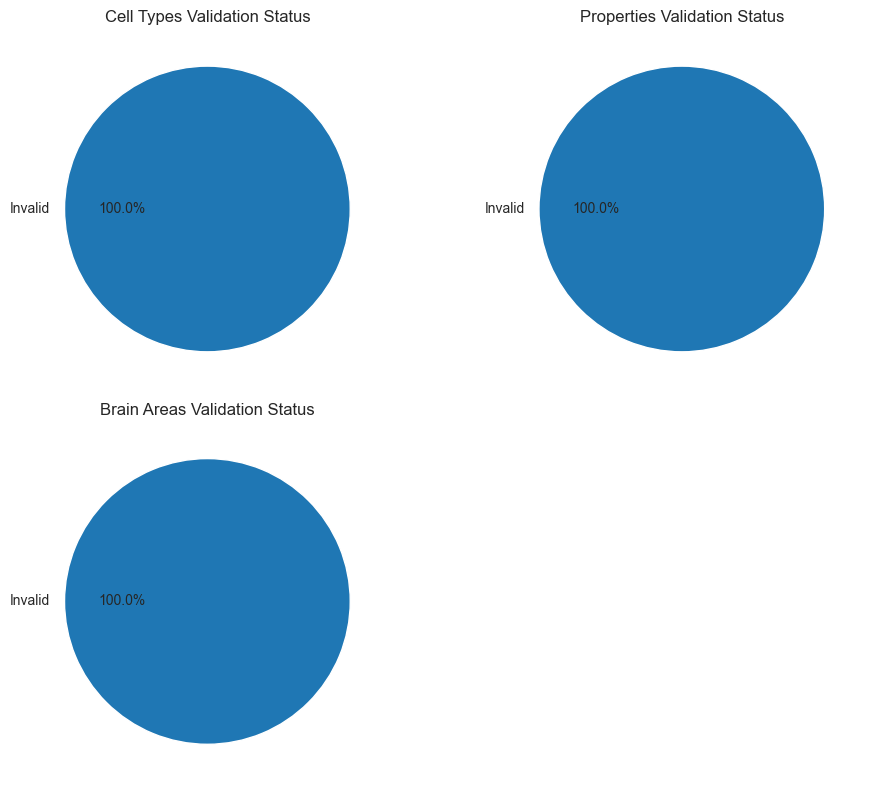

In [11]:
# Check valid flags in each dataset
print('Validation status:')
print(f"Cell types - valid: {celltypes_df['valid'].sum()} / {len(celltypes_df)}")
print(f"Properties - valid: {properties_df['valid'].sum()} / {len(properties_df)}")
print(f"Areas - valid: {areas_df['valid'].sum()} / {len(areas_df)}")
print(f"Proofreading - valid: {proofreading_df['valid'].sum()} / {len(proofreading_df)} (if 'valid' exists)" if 'valid' in proofreading_df.columns else "Proofreading - 'valid' column not found")

# Pie chart of valid vs invalid
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

datasets = [
    ('Cell Types', celltypes_df['valid'].value_counts()),
    ('Properties', properties_df['valid'].value_counts()),
    ('Brain Areas', areas_df['valid'].value_counts()),
]

for idx, (name, counts) in enumerate(datasets):
    ax = axes.flat[idx]
    counts.plot(kind='pie', ax=ax, autopct='%1.1f%%', labels=['Invalid', 'Valid'])
    ax.set_title(f'{name} Validation Status')
    ax.set_ylabel('')

# Remove the 4th subplot
fig.delaxes(axes.flat[3])

plt.tight_layout()
plt.show()

## Spatial Summary

Analyze the spatial distribution of neurons using position coordinates (x, y, z).

Valid position records: 144120 / 144120

Position statistics (microns):
       pt_position_x  pt_position_y  pt_position_z
count  144120.000000  144120.000000  144120.000000
mean   234163.053455  182152.695309   21157.395989
std     91074.431085   57097.624151    3651.079903
min     48576.000000   65568.000000   14834.000000
25%    156848.000000  135344.000000   18035.000000
50%    231488.000000  177408.000000   21140.000000
75%    309776.000000  230656.000000   24260.000000
max    426176.000000  310256.000000   27871.000000


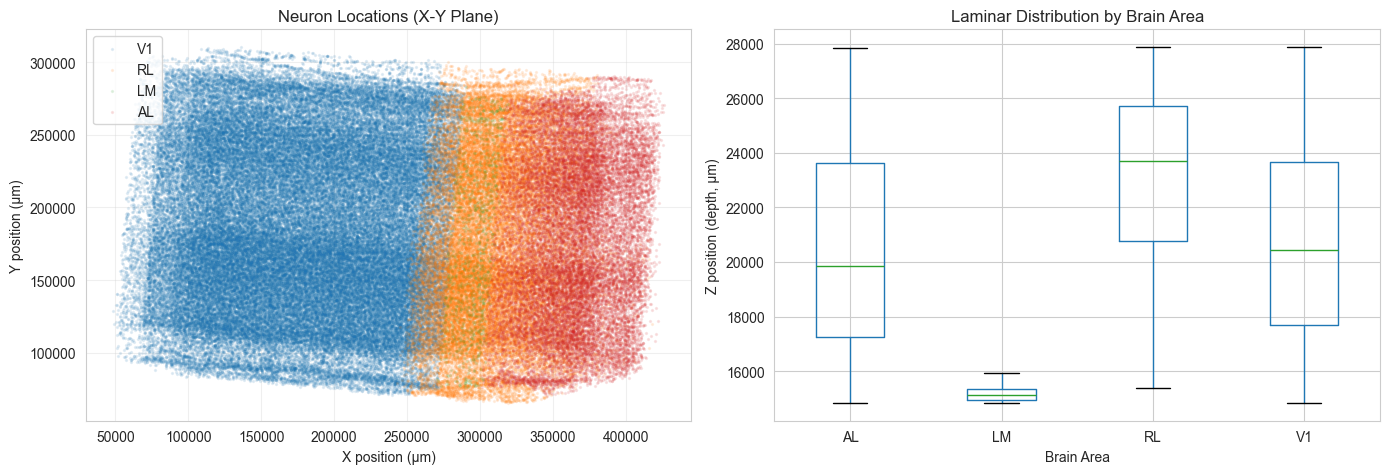

In [18]:
# Position statistics
position_cols = ['pt_position_x', 'pt_position_y', 'pt_position_z']
valid_positions = areas_df[position_cols].dropna()
print(f'Valid position records: {len(valid_positions)} / {len(areas_df)}')
print('\nPosition statistics (microns):')
print(valid_positions.describe())

# 3D scatter plot (project to 2D for visualization)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# X vs Y by brain area
for area in areas_df['tag'].unique():
    area_data = areas_df[areas_df['tag'] == area]
    axes[0].scatter(area_data['pt_position_x'], area_data['pt_position_y'], 
                    alpha=0.1, s=2, label=area)
axes[0].set_xlabel('X position (μm)')
axes[0].set_ylabel('Y position (μm)')
axes[0].set_title('Neuron Locations (X-Y Plane)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Z (depth) distribution by area
areas_df.boxplot(column='pt_position_z', by='tag', ax=axes[1])
axes[1].set_ylabel('Z position (depth, μm)')
axes[1].set_xlabel('Brain Area')
axes[1].set_title('Laminar Distribution by Brain Area')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

## Summary Statistics Table

Create a comprehensive summary of label counts across all structural annotations.

In [15]:
# Summary statistics
summary_stats = {
    'Total neurons (cell types)': len(celltypes_df),
    'Total neurons (properties)': len(properties_df),
    'Total voxel annotations (areas)': len(areas_df),
    'Unique cell types': celltypes_df['cell_type'].nunique(),
    'Unique brain areas': areas_df['tag'].nunique(),
    'Valid cell types': celltypes_df['valid'].sum(),
    'Valid area annotations': areas_df['valid'].sum(),
}

summary_df = pd.DataFrame(summary_stats.items(), columns=['Metric', 'Count'])
print('\nStructural Data Summary:')
print(summary_df.to_string(index=False))

# Label diversity
print('\n\nLabel Diversity:')
print(f'Cell type coverage: {(celltypes_df["valid"].sum() / len(celltypes_df) * 100):.1f}% valid records')
print(f'Brain areas: {sorted(areas_df["tag"].unique())}')
print(f'Classification systems: {sorted(celltypes_df["classification_system"].unique())}')


Structural Data Summary:
                         Metric  Count
     Total neurons (cell types)    347
     Total neurons (properties)  15780
Total voxel annotations (areas) 144120
              Unique cell types     15
             Unique brain areas      4
               Valid cell types    347
         Valid area annotations 144120


Label Diversity:
Cell type coverage: 100.0% valid records
Brain areas: ['AL', 'LM', 'RL', 'V1']
Classification systems: ['excitatory_neuron', 'inhibitory_neuron', 'nonneuron']
